In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#1. Types of data & variables

In [2]:

print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:

print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


####  LAB EXERCISE 1 — Classify the columns

1. Print the list of **numerical** columns and the list of **categorical** columns.
2. For a numerical column (e.g. `tip`), print its **mean**.
3. For a categorical column (e.g. `sex`), print its **value counts**.

In [14]:

numerical_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numerical columns:", numerical_columns.tolist())
print("Categorical columns:", categorical_columns.tolist())

print("Mean of tip:", df["tip"].mean())
print("Value counts of sex:")
print(df["sex"].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: []
Mean of tip: 2.99827868852459
Value counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


#2. Measures of central tendency

In [5]:

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


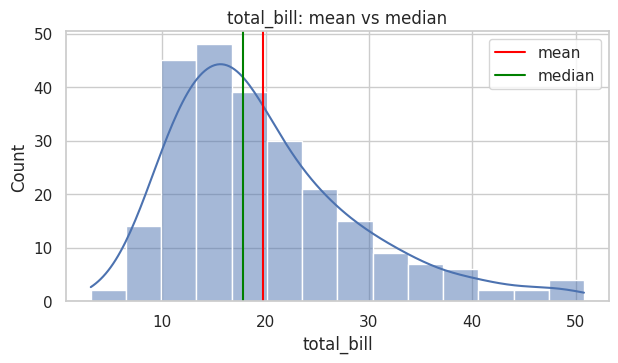

In [6]:

print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

####  LAB EXERCISE 2 — Central tendency

For the **`tip`** column:
1. Print its mean, median and mode.
2. Is it right-skewed? Check whether `mean > median`.
3. Plot a histogram of `tip` with vertical lines at the mean and median.

Mean: 2.99827868852459
Median: 2.9
Mode: 2.0
Mean > Median: True


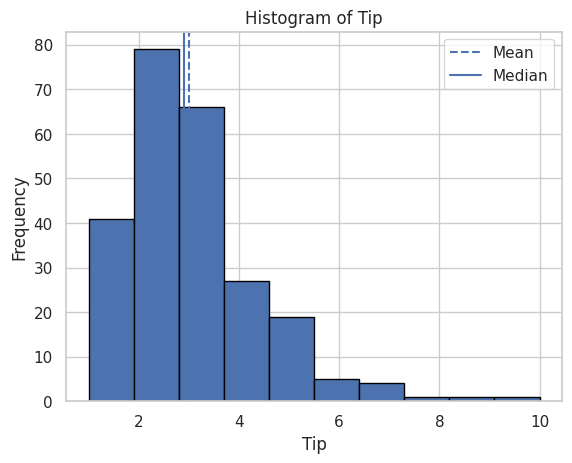

In [15]:

tip = df['tip']

mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()[0]

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip)

print("Mean > Median:", mean_tip > median_tip)


import matplotlib.pyplot as plt

plt.hist(tip, bins=10, edgecolor="black")
plt.axvline(mean_tip, linestyle="--", label="Mean")
plt.axvline(median_tip, linestyle="-", label="Median")

plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.title("Histogram of Tip")
plt.legend()
plt.show()

#3. Measures of spread (dispersion)

In [7]:


col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [8]:

q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [16]:
tip = df['tip']


tip_range = tip.max() - tip.min()
tip_variance = tip.var()
tip_std = tip.std()

print("Range:", tip_range)
print("Variance:", tip_variance)
print("Standard deviation:", tip_std)

Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Most robust measure of spread: IQR")

Range: 9.0
Variance: 1.9144546380624725
Standard deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625
Most robust measure of spread: IQR


#4. Shape: five-number summary & box plot

In [9]:


col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


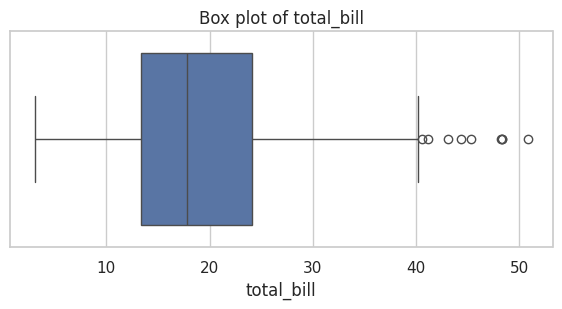

In [10]:

plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

#### LAB EXERCISE 4 — Five-number summary & box plot

For the **`tip`** column:
1. Print its five-number summary (min, 25%, 50%, 75%, max).
2. Print its skewness and say (in a comment) which way it leans.
3. Draw a box plot of `tip`.

Five-number summary:
Minimum: 1.0
Q1: 2.0
Median: 2.9
Q3: 3.5625
Maximum: 10.0

Skewness: 1.4654510370979401
The distribution is right-skewed (leans to the right).


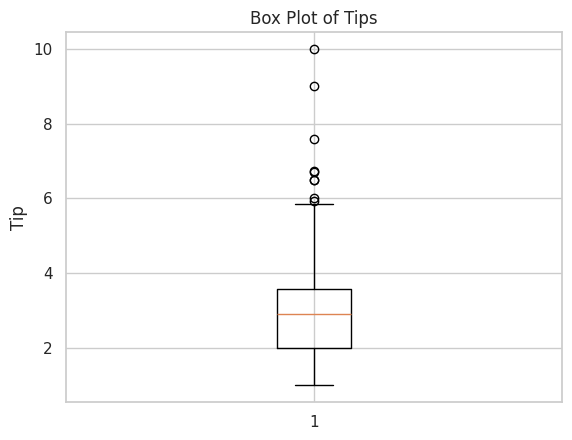

In [17]:
tip = df['tip']

minimum = tip.min()
Q1 = tip.quantile(0.25)
median = tip.median()
Q3 = tip.quantile(0.75)
maximum = tip.max()

print("Five-number summary:")
print("Minimum:", minimum)
print("Q1:", Q1)
print("Median:", median)
print("Q3:", Q3)
print("Maximum:", maximum)


skewness = tip.skew()

print("\nSkewness:", skewness)

if skewness > 0:
    print("The distribution is right-skewed (leans to the right).")
elif skewness < 0:
    print("The distribution is left-skewed (leans to the left).")
else:
    print("The distribution is approximately symmetric.")

import matplotlib.pyplot as plt

plt.boxplot(tip)
plt.ylabel("Tip")
plt.title("Box Plot of Tips")
plt.show()

#5. Correlation & summarizing a dataset

In [11]:

corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


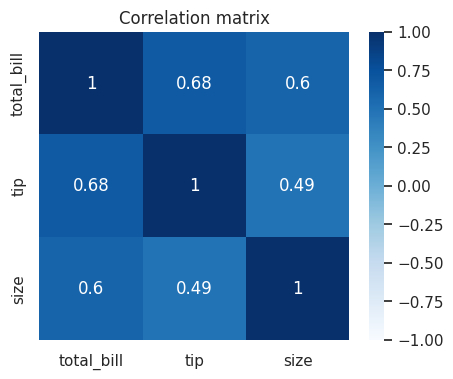

In [12]:


plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [13]:

df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


####  LAB EXERCISE 5 — Correlation & full summary

1. Build the correlation matrix and print it (rounded to 2 decimals).
2. Draw a correlation **heatmap**.
3. Run `df.describe()` and, in a comment, write **3 insights** about the dataset (e.g. which column is most spread out, which pair is most correlated, any skew you notice).

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


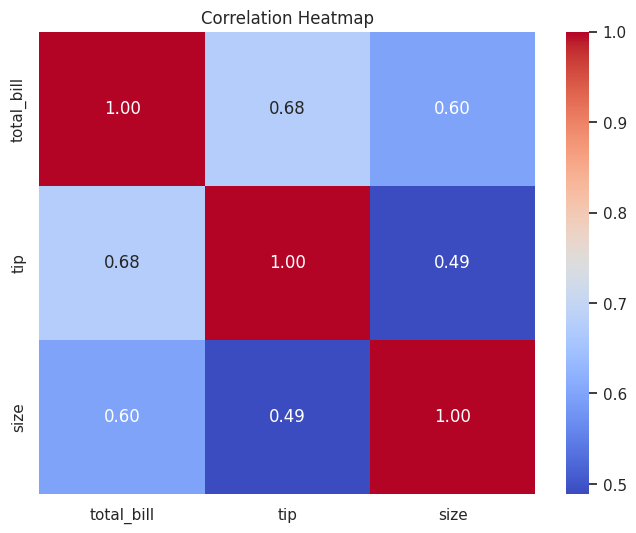

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [18]:

corr = df.corr(numeric_only=True)
print(corr.round(2))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

print(df.describe())
